# Laboratório 05: Dados Ausentes - Tratamento Univariado (Simples)
**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Objetivo:** Aprender a tomar a decisão crítica entre descartar (`dropna`) ou preencher (`fillna`) buracos nos dados usando medidas de tendência central (Média, Mediana e Moda).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

## Parte 1: Exemplo Guiado - A "Faca" e a "Seringa"
Neste exemplo rápido, usaremos o `.dropna()` (a faca) para amputar o que não tem salvação e o `.fillna()` (a seringa) para curar colunas numéricas e categóricas do nosso DataFrame de pacientes.

In [2]:
# Criando dados fictícios
df_exemplo = pd.DataFrame({
    'Paciente': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'Idade': [25, np.nan, 42, 38, np.nan],         # Numérica
    'Pressao': [120, 125, 130, np.nan, 140],       # Numérica
    'Tipo_Sanguineo': ['O+', 'A-', np.nan, 'O+', np.nan], # Categórica
    'Coluna_Perdida': [np.nan, np.nan, np.nan, np.nan, np.nan] # 100% Nula
})

print("Estado Original:\n", df_exemplo, "\n")

# 1. A Faca: Descartando colunas 100% vazias (axis=1 atinge colunas)
df_exemplo.dropna(axis=1, how='all', inplace=True)

# 2. A Seringa (Numéricos): Preenchendo Idade com a Mediana
mediana_idade = df_exemplo['Idade'].median()
df_exemplo['Idade'].fillna(mediana_idade, inplace=True)

# 3. A Seringa (Categóricos): Preenchendo Tipo Sanguíneo com a Moda
moda_sangue = df_exemplo['Tipo_Sanguineo'].mode()[0] #  pega a primeira moda se houver empate
df_exemplo['Tipo_Sanguineo'].fillna(moda_sangue, inplace=True)

print("Estado Tratado:\n", df_exemplo)

Estado Original:
   Paciente  Idade  Pressao Tipo_Sanguineo  Coluna_Perdida
0      Ana   25.0    120.0             O+             NaN
1    Bruno    NaN    125.0             A-             NaN
2   Carlos   42.0    130.0            NaN             NaN
3    Diana   38.0      NaN             O+             NaN
4  Eduardo    NaN    140.0            NaN             NaN 

Estado Tratado:
   Paciente  Idade  Pressao Tipo_Sanguineo
0      Ana   25.0    120.0             O+
1    Bruno   38.0    125.0             A-
2   Carlos   42.0    130.0             O+
3    Diana   38.0      NaN             O+
4  Eduardo   38.0    140.0             O+


## Parte 2: Exercício Prático (Mão na Massa)
Abaixo geramos um pequeno dataset de imóveis (`df_imoveis`). 
**Sua Tarefa:**
1. Descarte as colunas que possuam **mais de 70%** de valores nulos.
2. Preencha a coluna numérica `Preco` usando a estatística adequada (Média ou Mediana? Dica: Verifique se existem outliers absurdos com `.describe()`).
3. Preencha a coluna categórica `Bairro` com o valor mais comum (Moda).

In [3]:
# NÃO ALTERE ESTE CÓDIGO
np.random.seed(42)
df_imoveis = pd.DataFrame({
    'ID_Imovel': range(1, 101),
    'Bairro': np.random.choice(['Centro', 'Jardins', 'Vila Nova'], 100, p=[0.5, 0.3, 0.2]),
    'Preco': np.append(np.random.normal(300000, 50000, 95), [1500000, 2000000, 2500000, 3000000, 5000000]), # Com outliers milionários
    'Comissao_Corretor_Morta': [np.nan] * 100 # Coluna inútil
})

# Injetando nulos
df_imoveis.loc[np.random.choice(100, 15, replace=False), 'Preco'] = np.nan
df_imoveis.loc[np.random.choice(100, 20, replace=False), 'Bairro'] = np.nan

In [5]:
# Passo 1: dropna para remover coluna totalmente nula
df_imoveis = df_imoveis.dropna(axis=1, how="all")

# Passo 2: usar mediana para Preco (há outliers milionários)
mediana_preco = df_imoveis["Preco"].median()
df_imoveis["Preco"] = df_imoveis["Preco"].fillna(mediana_preco)

# Passo 3: usar moda para Bairro
moda_bairro = df_imoveis["Bairro"].mode()[0]
df_imoveis["Bairro"] = df_imoveis["Bairro"].fillna(moda_bairro)

df_imoveis.head()


,ID_Imovel,Bairro,Preco
0,1,Centro,304352.353412
1,2,Vila Nova,285049.632477
2,3,Jardins,304588.038827
3,4,Jardins,200621.554270
4,5,Centro,304853.877467


---
## Parte 3: Desafio para Casa - O Pipeline do Engenheiro de Dados
Este desafio consolida as **Aulas 02 a 07**. Rode a célula abaixo para gerar um arquivo CSV no seu disco chamado `ecommerce_messy.csv`.

**A Missão:**
1. **(Aula 02):** Carregue o arquivo lidando com o separador `;` e o encoding `latin-1`.
2. **(Aula 05):** Audite e remova as linhas inteiramente duplicadas.
3. **(Aula 04):** Converta a coluna `Categoria` para o tipo `category` para salvar memória.
4. **(Aula 06):** Plote um `sns.heatmap` para ver onde estão os nulos.
5. **(Aula 07):** Faça a imputação: `Idade` (Numérica) e `Categoria` (Texto).
6. **(Aula 04):** Calcule o Ticket Médio (`Renda`) agrupado por `Categoria`.

In [4]:
# NÃO ALTERE ESTE CÓDIGO - Geração de dados sujos reais no disco
np.random.seed(10)
n = 800
df_desafio = pd.DataFrame({
    'ID_Cliente': np.random.randint(1000, 9999, n),
    'Idade': np.random.normal(35, 10, n),
    'Renda': np.random.normal(5000, 2000, n),
    'Categoria': np.random.choice(['Eletrônicos', 'Móveis', 'Vestuário'], n)
})

# Inserindo buracos (NaNs)
df_desafio.loc[np.random.choice(n, 120, replace=False), 'Idade'] = np.nan
df_desafio.loc[np.random.choice(n, 60, replace=False), 'Categoria'] = np.nan

# Inserindo linhas duplicadas
df_desafio = pd.concat([df_desafio, df_desafio.sample(45)], ignore_index=True)

# Exportando para o formato legado "Brasileiro"
df_desafio.to_csv('ecommerce_messy.csv', sep=';', encoding='latin-1', index=False)
print("Arquivo 'ecommerce_messy.csv' gerado na sua pasta local!")

Arquivo 'ecommerce_messy.csv' gerado na sua pasta local!


Shape inicial: (845, 4)
Linhas duplicadas: 45
Shape após deduplicação: (800, 4)
Memória Categoria antes: 62762 bytes
Memória Categoria depois: 7529 bytes


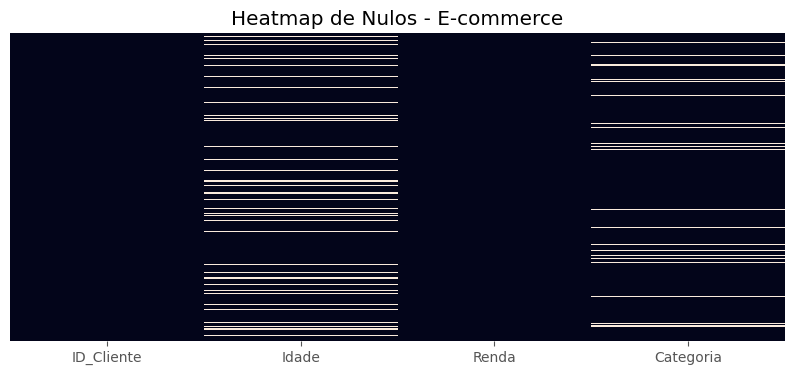

             qtd_clientes  idade_media  renda_media
Categoria                                          
Móveis                326    34.493795  4968.082803
Eletrônicos           240    35.419131  4896.284120
Vestuário             234    34.802260  4887.134394


In [6]:
# 1. Carregue o CSV (read_csv com sep e encoding corretos)
df_ecommerce = pd.read_csv("ecommerce_messy.csv", sep=";", encoding="latin-1")
print(f"Shape inicial: {df_ecommerce.shape}")

# 2. Remova duplicatas (.drop_duplicates)
duplicadas = df_ecommerce.duplicated().sum()
print(f"Linhas duplicadas: {duplicadas}")
df_ecommerce = df_ecommerce.drop_duplicates()
print(f"Shape após deduplicação: {df_ecommerce.shape}")

# 3. Otimização de tipo (.astype('category'))
mem_antes = df_ecommerce["Categoria"].memory_usage(deep=True)
df_ecommerce["Categoria"] = df_ecommerce["Categoria"].astype("category")
mem_depois = df_ecommerce["Categoria"].memory_usage(deep=True)
print(f"Memória Categoria antes: {mem_antes} bytes")
print(f"Memória Categoria depois: {mem_depois} bytes")

# 4. Heatmap do Seaborn (sns.heatmap)
plt.figure(figsize=(10, 4))
sns.heatmap(df_ecommerce.isnull(), cbar=False, cmap="rocket", yticklabels=False)
plt.title("Heatmap de Nulos - E-commerce")
plt.show()

# 5. Tratamento Univariado (fillna com mediana/moda)
mediana_idade = df_ecommerce["Idade"].median()
df_ecommerce["Idade"] = df_ecommerce["Idade"].fillna(mediana_idade)

moda_categoria = df_ecommerce["Categoria"].mode()[0]
df_ecommerce["Categoria"] = df_ecommerce["Categoria"].fillna(moda_categoria)

# 6. Análise Agrupada (groupby)
analise = (
    df_ecommerce.groupby("Categoria", observed=False)
    .agg(
        qtd_clientes=("ID_Cliente", "count"),
        idade_media=("Idade", "mean"),
        renda_media=("Renda", "mean"),
    )
    .sort_values("renda_media", ascending=False)
)
print(analise)
